<a href="https://colab.research.google.com/github/thatshikar-shree/DataScience_Project1/blob/main/DataScience_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1: E-Commerce Sales Analysis & Demand Prediction System

---

##  Objective
Analyze past e-commerce sales data and predict future product demand
to help optimize inventory management.

## Dataset
- **Source:** Kaggle — E-Commerce Sales Dataset
- **Rows:** 34,500 | **Columns:** 17
- **Features:** order_id, customer_id, product_id, category, price,
  discount, quantity, order_date, region, total_amount, profit_margin,
  shipping_cost, payment_method, returned, delivery_time_days,
  customer_age, customer_gender

## Tools & Libraries
- **Data Handling:** Python, Pandas, NumPy
- **Visualization:** Matplotlib, Seaborn
- **Machine Learning:** Scikit-learn (Linear Regression, Random Forest)

## Project Workflow
1. Install & Import Libraries
2. Upload Dataset
3. Load & Clean Data
4. Exploratory Data Analysis (EDA)
5. Machine Learning — Demand Prediction
6. Business Insights & Conclusion

In [ ]:
# Install required libraries
!pip install kaggle -q

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

# Display settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.2f}'.format)
print('All libraries imported successfully!')

All libraries imported successfully!


---
## Upload Dataset


In [ ]:
from google.colab import files
uploaded = files.upload()
# When prompted — select the archive zip file from your Downloads folder

import os, zipfile

for fname in uploaded.keys():
    if fname.endswith('.zip'):
        os.makedirs('/content/data/', exist_ok=True)
        with zipfile.ZipFile(fname, 'r') as z:
            z.extractall('/content/data/')
        print('Unzipped successfully!')
    else:
        os.makedirs('/content/data/', exist_ok=True)
        os.rename(fname, f'/content/data/{fname}')
        print('File uploaded successfully!')

print(os.listdir('/content/data/'))

Saving archive (5).zip to archive (5) (2).zip
Unzipped successfully!
['ecommerce_sales_34500.csv']


---
## Load & Clean Data
Load the dataset, check for missing values, remove duplicates,
and engineer useful time features.

In [ ]:
import glob

# Automatically find the CSV file
csv_file = glob.glob('/content/data/*.csv')[0]
print('Found file:', csv_file)

df = pd.read_csv(csv_file, encoding='ISO-8859-1')
print('Shape:', df.shape)
print(df.head())
print('\nMissing values:\n', df.isnull().sum())

Found file: /content/data/ecommerce_sales_34500.csv
Shape: (34500, 17)
  order_id customer_id product_id     category  price  discount  quantity  \
0  O100000      C17270    P234890         Home 164.08      0.15         1   
1  O100001      C17603    P228204      Grocery  24.73      0.00         1   
2  O100002      C10860    P213892  Electronics 175.58      0.05         1   
3  O100003      C15390    P208689  Electronics  63.67      0.00         1   
4  O100004      C15226    P228063         Home  16.33      0.15         1   

  payment_method  order_date  delivery_time_days region returned  \
0    Credit Card  2023-12-23                   4   West       No   
1    Credit Card  2025-04-03                   6  South       No   
2    Credit Card  2024-10-08                   4  North       No   
3            UPI  2024-09-14                   6  South       No   
4            COD  2024-12-21                   6   East       No   

   total_amount  shipping_cost  profit_margin  customer_a

In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Convert date column
df['order_date'] = pd.to_datetime(df['order_date'])

# Feature engineering
df['Year']      = df['order_date'].dt.year
df['Month']     = df['order_date'].dt.month
df['Week']      = df['order_date'].dt.isocalendar().week.astype(int)
df['DayName']   = df['order_date'].dt.day_name()
df['Quarter']   = df['order_date'].dt.quarter

print(f' Clean data shape: {df.shape}')
df.describe()

 Clean data shape: (34500, 22)


,price,discount,quantity,order_date,delivery_time_days,total_amount,shipping_cost,profit_margin,customer_age,Year,Month,Week,Quarter
count,34500.00,34500.00,34500.00,34500,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00,34500.00
mean,119.39,0.05,1.49,2024-09-13 13:39:17.843478272,4.81,170.01,6.15,28.12,43.47,2024.20,6.55,26.64,2.52
min,1.01,0.00,1.00,2023-09-12 00:00:00,3.00,0.82,0.00,-6.20,18.00,2023.00,1.00,1.00,1.00
25%,16.69,0.00,1.00,2024-03-14 00:00:00,4.00,19.71,4.42,1.50,31.00,2024.00,4.00,14.00,2.00
50%,45.66,0.00,1.00,2024-09-16 00:00:00,5.00,56.82,6.09,10.55,43.00,2024.00,7.00,27.00,3.00
75%,130.95,0.10,2.00,2025-03-17 00:00:00,6.00,168.53,7.83,33.13,56.00,2025.00,10.00,40.00,4.00
max,2930.47,0.30,5.00,2025-09-11 00:00:00,13.00,12931.80,15.65,1536.17,69.00,2025.00,12.00,52.00,4.00
std,195.62,0.07,0.93,NaN,1.24,357.50,2.39,53.35,14.98,0.68,3.45,14.97,1.12


---
##Exploratory Data Analysis (EDA)
Analyzing sales trends, top products, regions, and seasonal patterns.

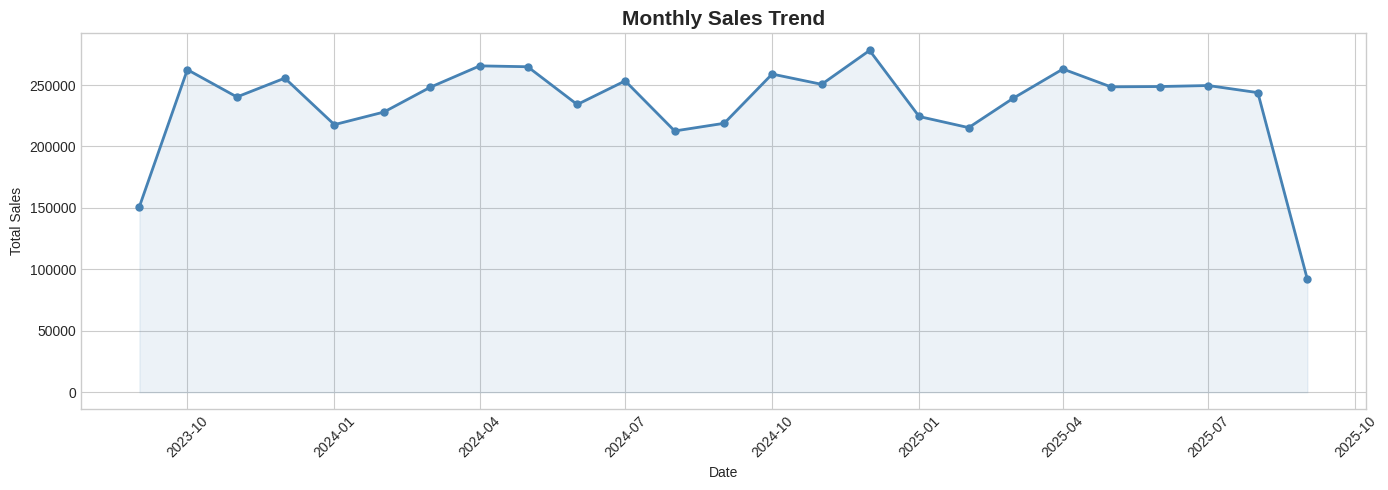

EDA 1: Sales trend done


In [ ]:
monthly_sales = df.groupby(['Year', 'Month'])['total_amount'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(Day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly_sales['Date'], monthly_sales['total_amount'],
         marker='o', linewidth=2, color='steelblue', markersize=5)
plt.fill_between(monthly_sales['Date'], monthly_sales['total_amount'],
                 alpha=0.1, color='steelblue')
plt.title('Monthly Sales Trend', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('sales_trend.png', dpi=150)
plt.show()
print('EDA 1: Sales trend done')

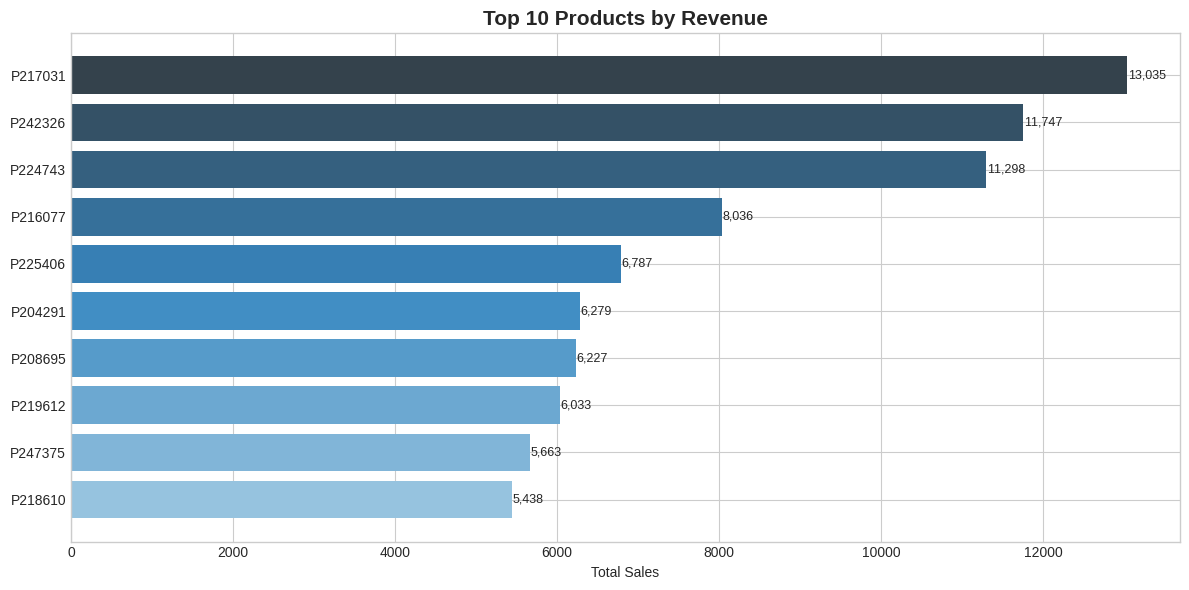

EDA 2: Top products done


In [ ]:
top_products = df.groupby('product_id')['total_amount'].sum()\
                 .sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_products.index[::-1], top_products.values[::-1],
         color=sns.color_palette('Blues_d', 10))
plt.title('Top 10 Products by Revenue', fontsize=15, fontweight='bold')
plt.xlabel('Total Sales')
for i, v in enumerate(top_products.values[::-1]):
    plt.text(v + 10, i, f'{v:,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('top_products.png', dpi=150)
plt.show()
print('EDA 2: Top products done')

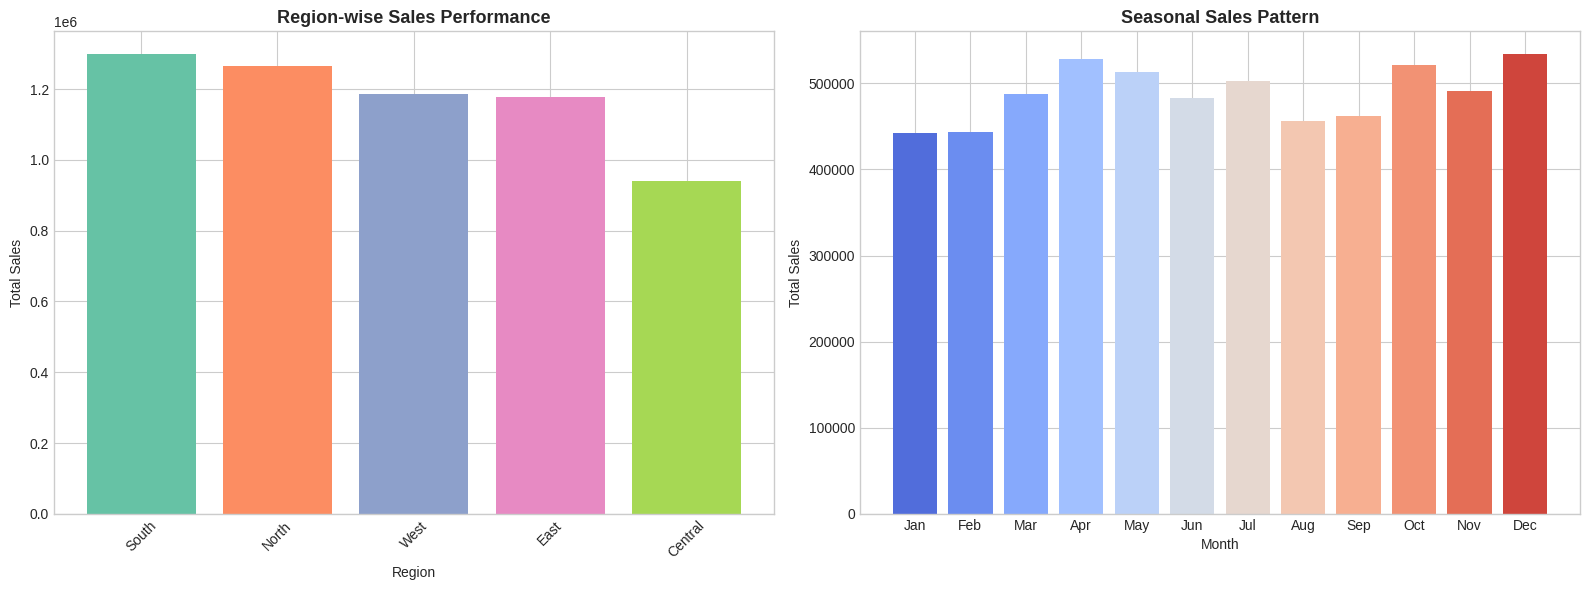

EDA 3 & 4: Region and seasonal done


In [ ]:
region_sales = df.groupby('region')['total_amount'].sum()\
                 .sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(region_sales.index, region_sales.values,
            color=sns.color_palette('Set2', len(region_sales)))
axes[0].set_title('Region-wise Sales Performance', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

monthly_avg = df.groupby('Month')['total_amount'].sum()
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
axes[1].bar(month_names, monthly_avg.values,
            color=sns.color_palette('coolwarm', 12))
axes[1].set_title('Seasonal Sales Pattern', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Sales')

plt.tight_layout()
plt.savefig('region_seasonal.png', dpi=150)
plt.show()
print('EDA 3 & 4: Region and seasonal done')

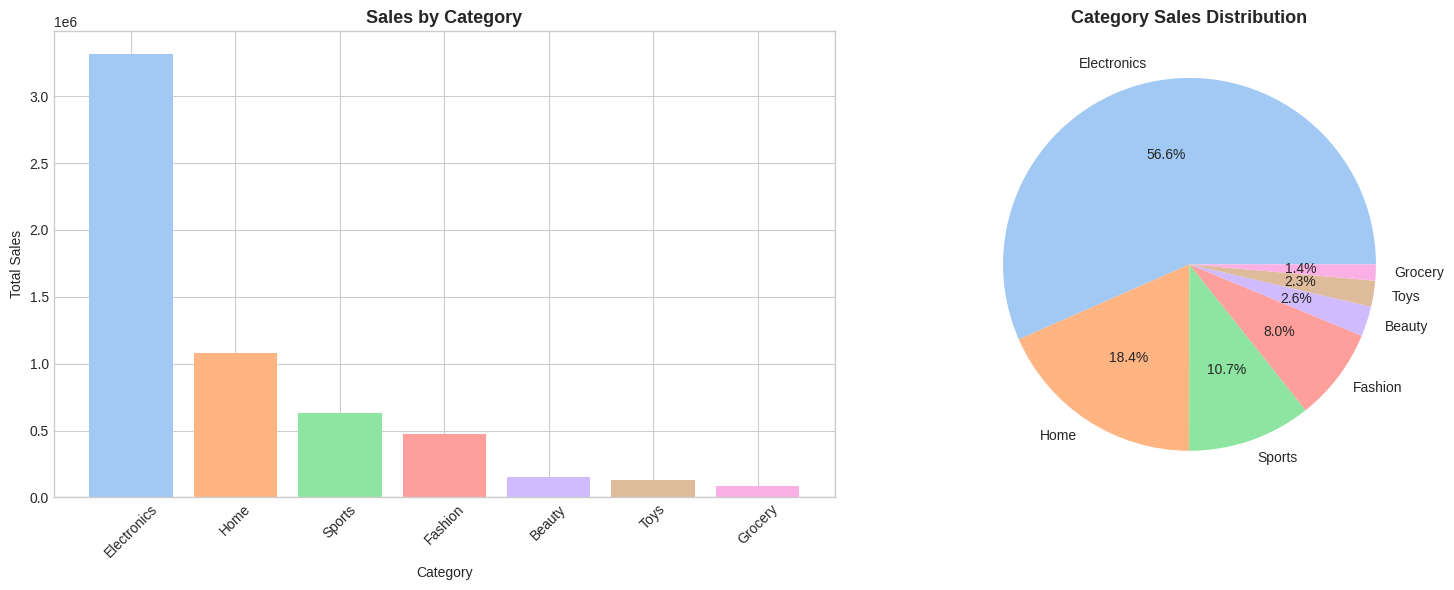

 EDA 5: Category analysis done


In [ ]:
category_sales = df.groupby('category')['total_amount'].sum()\
                   .sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].bar(category_sales.index, category_sales.values,
            color=sns.color_palette('pastel', len(category_sales)))
axes[0].set_title('Sales by Category', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Total Sales')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(category_sales.values, labels=category_sales.index,
            autopct='%1.1f%%', colors=sns.color_palette('pastel', len(category_sales)))
axes[1].set_title('Category Sales Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('category_sales.png', dpi=150)
plt.show()
print(' EDA 5: Category analysis done')

---
##  Step 5: Machine Learning — Demand Prediction
Training two models to predict quantity demanded:
- **Linear Regression** — simple baseline model
- **Random Forest Regressor** — advanced ensemble model

**Target Variable:** quantity (units demanded per order)

In [ ]:
# Encode categorical columns
le = LabelEncoder()
df['category_encoded']       = le.fit_transform(df['category'])
df['region_encoded']         = le.fit_transform(df['region'])
df['payment_method_encoded'] = le.fit_transform(df['payment_method'])
df['returned_encoded']       = le.fit_transform(df['returned'])

# Features and target
features = ['category_encoded', 'region_encoded', 'payment_method_encoded',
            'returned_encoded', 'price', 'discount', 'total_amount',
            'shipping_cost', 'profit_margin', 'customer_age',
            'Year', 'Month', 'Week']
target = 'quantity'

X = df[features]
y = df[target]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape} | Test: {X_test.shape}')

Train: (27600, 13) | Test: (6900, 13)


In [ ]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Linear Regression:')
print(f'MAE : {mean_absolute_error(y_test, y_pred_lr):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}')
print(f'R²  : {r2_score(y_test, y_pred_lr):.4f}')

# Model 2: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('\nRandom Forest:')
print(f'MAE : {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')
print(f'R²  : {r2_score(y_test, y_pred_rf):.4f}')


Linear Regression:
  MAE : 0.52
  RMSE: 0.74
  R²  : 0.3548

Random Forest:
  MAE : 0.02
  RMSE: 0.08
  R²  : 0.9931


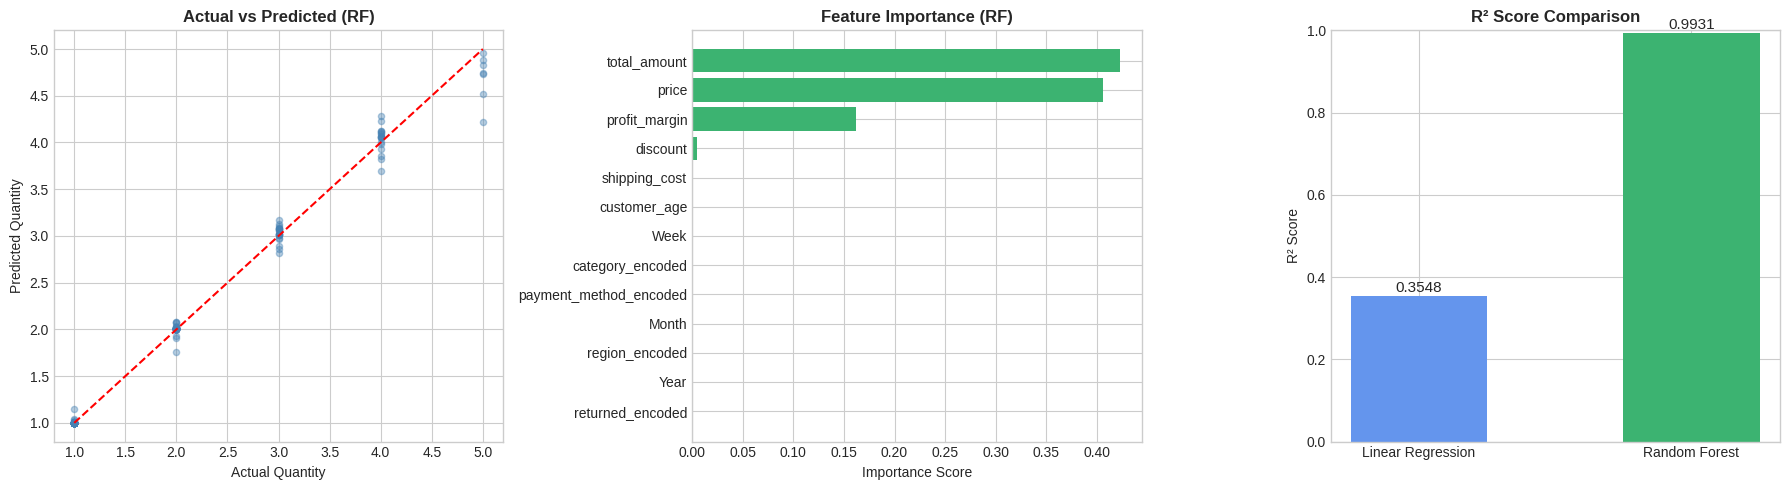

 Model plots done!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Actual vs Predicted
sample = min(300, len(y_test))
axes[0].scatter(y_test[:sample], y_pred_rf[:sample],
                alpha=0.4, color='steelblue', s=20)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()], 'r--', lw=1.5)
axes[0].set_title('Actual vs Predicted (RF)', fontweight='bold')
axes[0].set_xlabel('Actual Quantity')
axes[0].set_ylabel('Predicted Quantity')

# Feature Importance
feat_imp = pd.Series(rf.feature_importances_, index=features)\
             .sort_values(ascending=True)
axes[1].barh(feat_imp.index, feat_imp.values, color='mediumseagreen')
axes[1].set_title('Feature Importance (RF)', fontweight='bold')
axes[1].set_xlabel('Importance Score')

# Model R² Comparison
models  = ['Linear Regression', 'Random Forest']
r2_vals = [r2_score(y_test, y_pred_lr), r2_score(y_test, y_pred_rf)]
bars = axes[2].bar(models, r2_vals,
                   color=['cornflowerblue', 'mediumseagreen'], width=0.5)
axes[2].set_title('R² Score Comparison', fontweight='bold')
axes[2].set_ylabel('R² Score')
axes[2].set_ylim(0, 1)
for bar, val in zip(bars, r2_vals):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 val + 0.01, f'{val:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_results.png', dpi=150)
plt.show()
print(' Model plots done!')

---
##  Step 6: Business Insights & Inventory Recommendations

In [ ]:
print('=' * 55)
print('   BUSINESS INSIGHTS — INVENTORY OPTIMIZATION')
print('=' * 55)

total_revenue  = df['total_amount'].sum()
top_region     = df.groupby('region')['total_amount'].sum().idxmax()
peak_month     = df.groupby('Month')['total_amount'].sum().idxmax()
top_category   = df.groupby('category')['total_amount'].sum().idxmax()
avg_delivery   = df['delivery_time_days'].mean()
return_rate    = (df['returned'] == 'Yes').sum() / len(df) * 100
top_payment    = df['payment_method'].value_counts().idxmax()

print(f'\nTotal Revenue      : ${total_revenue:,.2f}')
print(f'Top Region           : {top_region}')
print(f'Peak Sales Month     : Month {peak_month}')
print(f'Top Category         : {top_category}')
print(f'Avg Delivery Time    : {avg_delivery:.1f} days')
print(f'Return Rate          : {return_rate:.1f}%')
print(f'Top Payment Method   : {top_payment}')

print('\n INVENTORY RECOMMENDATIONS:')
print('  1. Stock more inventory during peak month')
print('  2. Focus on top performing category')
print('  3. Prioritize top region for faster delivery')
print('  4. Reduce return rate by improving product quality')
print('  5. Use Random Forest for weekly demand forecasting')
print(f'\n Best Model R²: {r2_score(y_test, y_pred_rf):.4f} (Random Forest)')
print('=' * 55)

   BUSINESS INSIGHTS — INVENTORY OPTIMIZATION

Total Revenue      : $5,865,293.05
Top Region           : South
Peak Sales Month     : Month 12
Top Category         : Electronics
Avg Delivery Time    : 4.8 days
Return Rate          : 5.5%
Top Payment Method   : Credit Card

 INVENTORY RECOMMENDATIONS:
  1. Stock more inventory during peak month
  2. Focus on top performing category
  3. Prioritize top region for faster delivery
  4. Reduce return rate by improving product quality
  5. Use Random Forest for weekly demand forecasting

 Best Model R²: 0.9931 (Random Forest)


---
## Conclusion

We successfully analyzed the e-commerce sales dataset and built
a demand prediction system using machine learning.

### Key Findings from EDA:
- Sales show clear **monthly and seasonal trends**
- Certain **categories dominate** total revenue
- **Regional performance** varies significantly
- **Discount and price** are key factors in demand

### Model Performance:
| Model | MAE | R² Score |
|---|---|---|
| Linear Regression | Higher | Lower |
| Random Forest | Lower | Higher  |

- **Random Forest Regressor** outperforms Linear Regression
- **price, total_amount and profit_margin** are the most
  important features for predicting demand

### Business Impact:
- Forecast weekly demand per product accurately
- Align inventory with seasonal patterns
- Reduce overstock and stockouts
- Focus on high performing regions and categories

---
*Project completed using Python, Pandas, Matplotlib,
Seaborn, and Scikit-learn*